# Single-simulation multi-diagram spread analysis

Jupytext percent-format script for seed 00, Sigma_cloud=0.1 g cm^-2,
epsilon_ff=0.03. It analyzes:

- log(L/Lsun) vs Teff
- F070W-F200W vs F200W
- F182M-F200W vs F200W
- F140M-F162M vs F162M
- HST F555W-F814W vs F814W

Six physical Teff bins spanning 3000--3600 K are mapped through the
isochrone nearest each snapshot age into color bins for every CMD.
Within each bin, spread is the mean of the upper 25% of y minus the
mean of the lower 25% of y. The global metric is the mean over valid bins.

In [1]:
from __future__ import annotations

import contextlib
import io
import math
import os
import shutil
import sys
import warnings
from dataclasses import dataclass
from pathlib import Path
from typing import Sequence

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from astropy.table import Column, Table
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

from spisea import atmospheres, reddening, synthetic
from nbody6tools import Reader
from nbody62spisea import converter

sys.path.append('/home/wyz5rge/synthetic-cmd-dev/cmd_generator')
import interpolator  # noqa: E402

/home/wyz5rge/.venv/nbody/lib/python3.11/site-packages/pysynphot/locations.py:345: UserWarning: Extinction files not found in /home/wyz5rge/SPISEA/cdbs/extinction
  warnings.warn('Extinction files not found in %s' % (extdir, ))


particles.bound_subset and particles.bound_indexes will raise ImportError


## Configuration

In [2]:
UPDATED_MERGED_ROOT = Path(
    '/home/wyz5rge/SPISEA/evolution/merged/'
    'baraffe_pisa_ekstrom_parsec/'
)
SIMULATION_PATH = Path(
    '/standard/Tan_JC/backup_protoclusters/multiples/M3000new/'
    'sigma0p1/fiducial/sfe_ff003/00'
)
OUTPUT_DIR = Path.cwd() / 'single_sim_multi_diagram_spread_outputs'
ISO_CACHE_DIR = Path.cwd() / 'single_sim_multi_diagram_iso_cache'

RESET_ISO_CACHE = False
SAVE_FIGURES = True
SHOW_FIGURES = True
SAVE_INTERPOLATED_CATALOGS = True

USE_ROTATING_MERGED = False
AKS = 0.0
DISTANCE_PC = 410.0
METALLICITY = 0.0
ATM_FUNC = atmospheres.get_BTSettl_2015_atmosphere
RED_LAW = reddening.RedLawHosek18b()

ISO_AGES_MYR = np.arange(1.0, 20.0 + 0.25, 0.5)
ISO_LOG_AGES = np.log10(ISO_AGES_MYR * 1.0e6)
ANALYSIS_TIMES_MYR = np.arange(1.0, 20.0 + 0.25, 0.5)
DISPLAY_TIMES_MYR = np.array([1.0, 2.0, 3.0, 5.0, 7.5, 10.0, 15.0, 20.0])

TEFF_BIN_EDGES_K = np.linspace(3000.0, 3600.0, 7)
N_TEMPERATURE_BINS = len(TEFF_BIN_EDGES_K) - 1
MIN_STARS_PER_BIN = 8
CLIP_YOUNG_STARS_TO_GRID_MINIMUM = True

BIN_CMAP = plt.get_cmap('viridis')
AGE_CMAP = plt.get_cmap('coolwarm')
AGE_NORM = Normalize(ISO_AGES_MYR.min(), ISO_AGES_MYR.max())
L_SUN_WATTS = 3.846e26

FILTER_OBSMODES = {
    'F070W': 'jwst,F070W',
    'F140M': 'jwst,F140M',
    'F162M': 'jwst,F162M',
    'F182M': 'jwst,F182M',
    'F200W': 'jwst,F200W',
    'F555W': 'wfc3,uvis1,f555w',
    'F814W': 'wfc3,uvis1,f814w',
}
ALL_FILTERS = list(FILTER_OBSMODES.values())

## Diagram definitions

In [3]:
@dataclass(frozen=True)
class Diagram:
    key: str
    title: str
    x_label: str
    y_label: str
    kind: str
    blue: str | None = None
    red: str | None = None
    y_filter: str | None = None
    invert_x: bool = False
    invert_y: bool = False


DIAGRAMS = [
    Diagram(
        'hr', r'$\log(L/L_\odot)$ vs. $T_{\rm eff}$',
        r'$T_{\rm eff}$ [K]', r'$\log(L/L_\odot)$',
        'hr', invert_x=True,
    ),
    Diagram(
        'f070w_f200w', 'F070W - F200W vs. F200W',
        'F070W - F200W', 'F200W', 'cmd',
        'F070W', 'F200W', 'F200W', invert_y=True,
    ),
    Diagram(
        'f182m_f200w', 'F182M - F200W vs. F200W',
        'F182M - F200W', 'F200W', 'cmd',
        'F182M', 'F200W', 'F200W', invert_y=True,
    ),
    Diagram(
        'f140m_f162m', 'F140M - F162M vs. F162M',
        'F140M - F162M', 'F162M', 'cmd',
        'F140M', 'F162M', 'F162M', invert_y=True,
    ),
    Diagram(
        'hst_f555w_f814w', 'HST F555W - F814W vs. F814W',
        'F555W - F814W', 'F814W', 'cmd',
        'F555W', 'F814W', 'F814W', invert_y=True,
    ),
]

## Merged evolutionary-model reader

In [4]:
class MergedBaraffePisaEkstromParsecDAT:
    def __init__(self, root_dir: Path | str, rot: bool = False):
        self.root_dir = Path(root_dir).expanduser().resolve()
        self.rot = bool(rot)
        self.model_dir = str(self.root_dir)
        self.z_list = [0.015]
        self.z_solar = 0.015
        self.mass_list = []
        self.grid_dir = self.root_dir / ('z015_rot' if rot else 'z015_norot')

        if not self.grid_dir.is_dir():
            raise FileNotFoundError(self.grid_dir)

        self.age_file_map = {}
        for path in sorted(self.grid_dir.glob('iso_*.dat')):
            try:
                log_age = float(path.stem.split('_')[1])
            except (IndexError, ValueError):
                continue
            self.age_file_map[round(log_age, 2)] = path

        if not self.age_file_map:
            raise FileNotFoundError(f'No iso_*.dat files in {self.grid_dir}')
        self.age_list = np.array(sorted(self.age_file_map), dtype=float)

    def isochrone(self, age: float = 1.0e6, metallicity: float = 0.0) -> Table:
        requested = math.log10(age)
        if requested < self.age_list[0] or requested > self.age_list[-1]:
            raise ValueError(f'logAge {requested:.4f} outside merged grid')

        idx = int(np.argmin(np.abs(self.age_list - requested)))
        selected = float(self.age_list[idx])
        path = self.age_file_map[round(selected, 2)]
        dtype = [
            ('mass', 'f8'), ('logT', 'f8'), ('logL', 'f8'),
            ('logg', 'f8'), ('logT_WR', 'f8'), ('mass_current', 'f8'),
            ('phase', 'i4'), ('model_ref', 'U32'),
        ]
        data = np.genfromtxt(path, comments='#', dtype=dtype, encoding='utf-8')
        iso = Table(np.atleast_1d(data))
        is_wr = ~np.isclose(
            np.asarray(iso['logT'], float), np.asarray(iso['logT_WR'], float),
            rtol=0.0, atol=1.0e-8,
        )
        iso.add_column(Column(is_wr, name='isWR'))
        iso.meta.update({
            'log_age': selected,
            'log_age_requested': requested,
            'metallicity_in': metallicity,
            'metallicity_act': 0.0,
            'source_file': str(path),
        })
        return iso

## General helpers and isochrone grid

In [5]:
@dataclass
class IsoGrid:
    ages_myr: np.ndarray
    log_ages: np.ndarray
    isochrones: list
    coverage: pd.DataFrame
    filter_columns: dict[str, str]


def prepare_directories():
    if RESET_ISO_CACHE and ISO_CACHE_DIR.exists():
        shutil.rmtree(ISO_CACHE_DIR)
    ISO_CACHE_DIR.mkdir(parents=True, exist_ok=True)
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


def finish_figure(fig, filename):
    if SAVE_FIGURES:
        fig.savefig(OUTPUT_DIR / filename, dpi=220, bbox_inches='tight')
    if SHOW_FIGURES:
        plt.show()
    else:
        plt.close(fig)


def normalize_name(name):
    return ''.join(ch.lower() for ch in str(name) if ch.isalnum())


def resolve_filter_column(colnames, filter_name):
    target = normalize_name(filter_name)
    candidates = [
        c for c in colnames
        if normalize_name(c).startswith('m') and normalize_name(c).endswith(target)
    ]
    instrument = 'hst' if filter_name in {'F555W', 'F814W'} else 'jwst'
    preferred = [c for c in candidates if instrument in normalize_name(c)]
    if len(preferred) == 1:
        return preferred[0]
    if len(candidates) == 1:
        return candidates[0]
    raise KeyError(
        f'Cannot uniquely resolve {filter_name}; candidates={candidates}; '
        f'available={list(colnames)}'
    )


def safe_interpolate(age_myr, mass, grid, log_ages, filters):
    try:
        with warnings.catch_warnings(), contextlib.redirect_stdout(io.StringIO()), \
                contextlib.redirect_stderr(io.StringIO()):
            warnings.simplefilter('ignore')
            result = interpolator.interpolate(
                age_myr, mass, grid, log_ages, list(filters)
            )
        if result is None:
            return None
        result = np.asarray(result, float)
        if result.size != 3 + len(filters) or not np.all(np.isfinite(result)):
            return None
        return result
    except Exception:
        return None


def build_iso_grid(evo_model):
    isochrones, records = [], []
    filter_columns = None

    for age_myr, log_age in zip(ISO_AGES_MYR, ISO_LOG_AGES):
        print(f'Building/loading {age_myr:4.1f} Myr isochrone')
        try:
            iso = synthetic.IsochronePhot(
                log_age, AKS, DISTANCE_PC,
                metallicity=METALLICITY,
                evo_model=evo_model,
                atm_func=ATM_FUNC,
                red_law=RED_LAW,
                filters=ALL_FILTERS,
                iso_dir=str(ISO_CACHE_DIR),
            )
            current = {
                name: resolve_filter_column(iso.points.colnames, name)
                for name in FILTER_OBSMODES
            }
            if filter_columns is None:
                filter_columns = current
                print('Resolved magnitude columns:')
                for key, value in current.items():
                    print(f'  {key}: {value}')
            elif current != filter_columns:
                raise RuntimeError('Magnitude-column names changed across ages')

            mass = np.asarray(iso.points['mass'], float)
            isochrones.append(iso)
            records.append({
                'age_myr': age_myr, 'status': 'success',
                'n_points': len(iso.points),
                'mass_min': np.nanmin(mass), 'mass_max': np.nanmax(mass),
                'error': '',
            })
        except Exception as exc:
            isochrones.append(None)
            records.append({
                'age_myr': age_myr, 'status': 'failed', 'n_points': 0,
                'mass_min': np.nan, 'mass_max': np.nan, 'error': str(exc),
            })
            print(f'  FAILED: {exc}')

    if filter_columns is None:
        raise RuntimeError('No photometric isochrones were built')
    return IsoGrid(
        ISO_AGES_MYR.copy(), ISO_LOG_AGES.copy(), isochrones,
        pd.DataFrame(records), filter_columns,
    )

In [6]:
prepare_directories()
if not SIMULATION_PATH.is_dir():
    raise FileNotFoundError(SIMULATION_PATH)

evo_model = MergedBaraffePisaEkstromParsecDAT(
    UPDATED_MERGED_ROOT, rot=USE_ROTATING_MERGED
)
ISO_GRID = build_iso_grid(evo_model)
display(ISO_GRID.coverage)
failed = ISO_GRID.coverage[ISO_GRID.coverage['status'] != 'success']
if len(failed):
    raise RuntimeError(
        'Isochrone failures:\n' + failed[['age_myr', 'error']].to_string(index=False)
    )

Building/loading  1.0 Myr isochrone
Resolved magnitude columns:
  F070W: m_jwst_F070W
  F140M: m_jwst_F140M
  F162M: m_jwst_F162M
  F182M: m_jwst_F182M
  F200W: m_jwst_F200W
  F555W: m_hst_f555w
  F814W: m_hst_f814w
Building/loading  1.5 Myr isochrone


Building/loading  2.0 Myr isochrone
Building/loading  2.5 Myr isochrone
Building/loading  3.0 Myr isochrone
Building/loading  3.5 Myr isochrone
Building/loading  4.0 Myr isochrone
Building/loading  4.5 Myr isochrone
Building/loading  5.0 Myr isochrone
Building/loading  5.5 Myr isochrone
Building/loading  6.0 Myr isochrone
Building/loading  6.5 Myr isochrone


Building/loading  7.0 Myr isochrone
Building/loading  7.5 Myr isochrone


Building/loading  8.0 Myr isochrone
Building/loading  8.5 Myr isochrone
Building/loading  9.0 Myr isochrone
Building/loading  9.5 Myr isochrone
Building/loading 10.0 Myr isochrone
Building/loading 10.5 Myr isochrone
Building/loading 11.0 Myr isochrone
Building/loading 11.5 Myr isochrone
Building/loading 12.0 Myr isochrone
Building/loading 12.5 Myr isochrone
Building/loading 13.0 Myr isochrone


Building/loading 13.5 Myr isochrone
Building/loading 14.0 Myr isochrone


Building/loading 14.5 Myr isochrone
Building/loading 15.0 Myr isochrone
Building/loading 15.5 Myr isochrone
Building/loading 16.0 Myr isochrone
Building/loading 16.5 Myr isochrone
Building/loading 17.0 Myr isochrone
Building/loading 17.5 Myr isochrone
Building/loading 18.0 Myr isochrone
Building/loading 18.5 Myr isochrone
Building/loading 19.0 Myr isochrone
Building/loading 19.5 Myr isochrone


Building/loading 20.0 Myr isochrone


,age_myr,status,n_points,mass_min,mass_max,error
0,1.0,success,1178,0.01,500.000,
1,1.5,success,1287,0.01,500.000,
2,2.0,success,1330,0.01,500.000,
3,2.5,success,2333,0.01,259.154,
4,3.0,success,1856,0.01,116.520,
5,3.5,success,1884,0.01,80.336,
6,4.0,success,1704,0.01,58.761,
7,4.5,success,1571,0.01,47.174,
8,5.0,success,1529,0.01,39.109,
9,5.5,success,1525,0.01,34.304,


## Snapshot loading and interpolation

In [7]:
def load_cluster_table(sim_path, snapshot_time_myr):
    path = os.path.abspath(str(sim_path))
    if not path.endswith('/'):
        path += '/'
    snapshot = Reader.read_snapshot(path, time=float(snapshot_time_myr))
    snapshot.to_physical()
    return converter.to_spicea_table(snapshot)


def interpolate_snapshot(table, grid):
    masses = np.asarray(table['mass'], float)
    ages = np.asarray(table['age'], float)
    names = list(FILTER_OBSMODES)
    keys = [grid.filter_columns[name] for name in names]
    min_age, max_age = float(grid.ages_myr.min()), float(grid.ages_myr.max())
    rows = []
    counters = dict(
        nonfinite_mass=0, nonfinite_age=0, younger_than_grid=0,
        older_than_grid=0, interpolation_failed=0,
        nonpositive_luminosity=0, retained=0,
    )

    for system_index, (mass, age) in enumerate(zip(masses, ages)):
        if not np.isfinite(mass):
            counters['nonfinite_mass'] += 1
            continue
        if not np.isfinite(age):
            counters['nonfinite_age'] += 1
            continue

        used_age = float(age)
        clipped = False
        if used_age < min_age:
            counters['younger_than_grid'] += 1
            if not CLIP_YOUNG_STARS_TO_GRID_MINIMUM:
                continue
            used_age, clipped = min_age, True
        if used_age > max_age:
            counters['older_than_grid'] += 1
            continue

        result = safe_interpolate(
            used_age, float(mass), grid.isochrones, grid.log_ages, keys
        )
        if result is None:
            counters['interpolation_failed'] += 1
            continue

        luminosity, teff, logg = map(float, result[:3])
        if luminosity <= 0:
            counters['nonpositive_luminosity'] += 1
            continue

        row = {
            'system_index': system_index,
            'mass': float(mass),
            'age_myr': float(age),
            'age_used_myr': used_age,
            'age_clipped_to_grid': clipped,
            'teff': teff,
            'luminosity_watts': luminosity,
            'log_luminosity_lsun': np.log10(luminosity / L_SUN_WATTS),
            'logg': logg,
        }
        row.update({f'mag_{n}': float(v) for n, v in zip(names, result[3:])})
        rows.append(row)
        counters['retained'] += 1

    df = pd.DataFrame(rows)
    df.attrs['interpolation_counters'] = counters
    return df

## Coordinates, mapped bins, and spread statistic

In [8]:
def nearest_iso_index(age_myr):
    age = np.clip(age_myr, ISO_GRID.ages_myr.min(), ISO_GRID.ages_myr.max())
    return int(np.argmin(np.abs(ISO_GRID.ages_myr - age)))


def catalog_xy(df, diagram):
    if diagram.kind == 'hr':
        return (
            df['teff'].to_numpy(float),
            df['log_luminosity_lsun'].to_numpy(float),
        )
    blue = df[f'mag_{diagram.blue}'].to_numpy(float)
    red = df[f'mag_{diagram.red}'].to_numpy(float)
    y = df[f'mag_{diagram.y_filter}'].to_numpy(float)
    return blue - red, y


def isochrone_xy(iso, diagram):
    teff = np.asarray(iso.points['Teff'], float)
    if diagram.kind == 'hr':
        luminosity = np.asarray(iso.points['L'], float)
        y = np.full_like(luminosity, np.nan)
        good = luminosity > 0
        y[good] = np.log10(luminosity[good] / L_SUN_WATTS)
        return teff, y, teff
    blue = np.asarray(iso.points[ISO_GRID.filter_columns[diagram.blue]], float)
    red = np.asarray(iso.points[ISO_GRID.filter_columns[diagram.red]], float)
    y = np.asarray(iso.points[ISO_GRID.filter_columns[diagram.y_filter]], float)
    return blue - red, y, teff


def mapped_x_edges(iso, diagram):
    if diagram.kind == 'hr':
        return TEFF_BIN_EDGES_K.copy()

    x, _, teff = isochrone_xy(iso, diagram)
    good = np.isfinite(x) & np.isfinite(teff)
    local = good & (teff >= TEFF_BIN_EDGES_K.min() - 100) \
                 & (teff <= TEFF_BIN_EDGES_K.max() + 100)
    x, teff = x[local], teff[local]
    if len(teff) < 2:
        return np.full_like(TEFF_BIN_EDGES_K, np.nan)

    order = np.argsort(teff)
    teff, x = teff[order], x[order]
    unique_teff, inverse = np.unique(teff, return_inverse=True)
    x_sum = np.zeros_like(unique_teff)
    count = np.zeros_like(unique_teff)
    np.add.at(x_sum, inverse, x)
    np.add.at(count, inverse, 1)
    x_unique = x_sum / count

    if TEFF_BIN_EDGES_K.min() < unique_teff.min() or \
            TEFF_BIN_EDGES_K.max() > unique_teff.max():
        return np.full_like(TEFF_BIN_EDGES_K, np.nan)
    return np.interp(TEFF_BIN_EDGES_K, unique_teff, x_unique)


def intervals(edges):
    return [(float(min(a, b)), float(max(a, b))) for a, b in zip(edges[:-1], edges[1:])]


def tail_spread(values):
    values = np.asarray(values, float)
    values = values[np.isfinite(values)]
    if len(values) == 0:
        return np.nan, np.nan, np.nan
    q25, q75 = np.quantile(values, [0.25, 0.75])
    lower = values[values <= q25]
    upper = values[values >= q75]
    if len(lower) == 0 or len(upper) == 0:
        return np.nan, np.nan, np.nan
    lower_mean, upper_mean = float(lower.mean()), float(upper.mean())
    return upper_mean - lower_mean, lower_mean, upper_mean


def measure(df, diagram, edges, snapshot_time, fiducial_age):
    x, y = catalog_xy(df, diagram)
    good = np.isfinite(x) & np.isfinite(y)
    x, y = x[good], y[good]
    per_bin = []

    for i, (x_low, x_high) in enumerate(intervals(edges)):
        mask = (x >= x_low) & ((x <= x_high) if i == N_TEMPERATURE_BINS - 1 else (x < x_high))
        y_bin = y[mask]
        if len(y_bin) >= MIN_STARS_PER_BIN:
            spread, lower_mean, upper_mean = tail_spread(y_bin)
        else:
            spread = lower_mean = upper_mean = np.nan

        per_bin.append({
            'snapshot_time_myr': snapshot_time,
            'fiducial_isochrone_age_myr': fiducial_age,
            'diagram': diagram.key,
            'diagram_title': diagram.title,
            'bin_index': i,
            'teff_low_k': TEFF_BIN_EDGES_K[i],
            'teff_high_k': TEFF_BIN_EDGES_K[i + 1],
            'x_low': x_low,
            'x_high': x_high,
            'n_stars': len(y_bin),
            'lower_tail_mean_y': lower_mean,
            'upper_tail_mean_y': upper_mean,
            'bin_spread': spread,
            'valid_bin': bool(np.isfinite(spread)),
        })

    valid = np.array([r['bin_spread'] for r in per_bin if r['valid_bin']], float)
    age_spread = np.percentile(df['age_myr'], 95) - np.percentile(df['age_myr'], 5)
    summary = {
        'snapshot_time_myr': snapshot_time,
        'fiducial_isochrone_age_myr': fiducial_age,
        'diagram': diagram.key,
        'diagram_title': diagram.title,
        'spread_metric': float(valid.mean()) if len(valid) else np.nan,
        'n_valid_bins': len(valid),
        'n_total_bins': N_TEMPERATURE_BINS,
        'n_catalog_stars': len(df),
        'age_spread_p95_minus_p05_myr': float(age_spread),
    }
    return summary, per_bin

## Run all requested snapshot times

In [9]:
snapshot_catalogs = {}
snapshot_iso_indices = {}
mapped_edges_cache = {}
metric_rows, bin_rows, accounting_rows = [], [], []

for snapshot_time in ANALYSIS_TIMES_MYR:
    print('=' * 72)
    print(f'Snapshot time: {snapshot_time:.1f} Myr')
    try:
        table = load_cluster_table(SIMULATION_PATH, snapshot_time)
    except Exception as exc:
        print(f'  load failed: {exc}')
        accounting_rows.append({
            'snapshot_time_myr': snapshot_time,
            'status': 'load_failed', 'error': str(exc),
            'n_input_systems': 0, 'n_retained_systems': 0,
        })
        continue

    df = interpolate_snapshot(table, ISO_GRID)
    counters = df.attrs['interpolation_counters']
    print(f'  retained {len(df)}/{len(table)} systems')
    print(f'  {counters}')
    if df.empty:
        accounting_rows.append({
            'snapshot_time_myr': snapshot_time,
            'status': 'empty_after_interpolation', 'error': str(counters),
            'n_input_systems': len(table), 'n_retained_systems': 0,
        })
        continue

    snapshot_time = float(snapshot_time)
    snapshot_catalogs[snapshot_time] = df
    iso_idx = nearest_iso_index(snapshot_time)
    snapshot_iso_indices[snapshot_time] = iso_idx
    fiducial_age = float(ISO_GRID.ages_myr[iso_idx])
    iso = ISO_GRID.isochrones[iso_idx]

    for diagram in DIAGRAMS:
        edges = mapped_x_edges(iso, diagram)
        mapped_edges_cache[(snapshot_time, diagram.key)] = edges
        if not np.all(np.isfinite(edges)):
            print(f'  {diagram.key}: bin mapping failed')
            continue
        summary, details = measure(df, diagram, edges, snapshot_time, fiducial_age)
        metric_rows.append(summary)
        bin_rows.extend(details)
        print(
            f"  {diagram.key}: spread={summary['spread_metric']:.4f}, "
            f"valid bins={summary['n_valid_bins']}/{N_TEMPERATURE_BINS}"
        )

    if SAVE_INTERPOLATED_CATALOGS:
        df.to_csv(
            OUTPUT_DIR / f'interpolated_catalog_t{snapshot_time:04.1f}myr.csv',
            index=False,
        )
    accounting_rows.append({
        'snapshot_time_myr': snapshot_time,
        'status': 'success', 'error': '',
        'n_input_systems': len(table), 'n_retained_systems': len(df),
        **counters,
    })


df_metrics = pd.DataFrame(metric_rows)
df_bins = pd.DataFrame(bin_rows)
df_accounting = pd.DataFrame(accounting_rows)

display(df_metrics.head())
display(df_bins.head())
display(df_accounting)

df_metrics.to_csv(OUTPUT_DIR / 'spread_metrics_by_time_and_diagram.csv', index=False)
df_bins.to_csv(OUTPUT_DIR / 'spread_metrics_per_bin.csv', index=False)
df_accounting.to_csv(OUTPUT_DIR / 'snapshot_accounting.csv', index=False)

Snapshot time: 1.0 Myr


  retained 543/543 systems
  {'nonfinite_mass': 0, 'nonfinite_age': 0, 'younger_than_grid': 437, 'older_than_grid': 0, 'interpolation_failed': 0, 'nonpositive_luminosity': 0, 'retained': 543}
  hr: spread=0.0774, valid bins=6/6
  f070w_f200w: spread=0.2024, valid bins=6/6
  f182m_f200w: spread=0.2045, valid bins=6/6
  f140m_f162m: spread=0.8352, valid bins=6/6
  hst_f555w_f814w: spread=0.2329, valid bins=6/6
Snapshot time: 1.5 Myr


  retained 756/756 systems
  {'nonfinite_mass': 0, 'nonfinite_age': 0, 'younger_than_grid': 423, 'older_than_grid': 0, 'interpolation_failed': 0, 'nonpositive_luminosity': 0, 'retained': 756}
  hr: spread=0.1611, valid bins=6/6
  f070w_f200w: spread=0.5476, valid bins=6/6
  f182m_f200w: spread=0.3426, valid bins=6/6
  f140m_f162m: spread=1.1588, valid bins=6/6
  hst_f555w_f814w: spread=0.4538, valid bins=6/6
Snapshot time: 2.0 Myr


  retained 1003/1003 systems
  {'nonfinite_mass': 0, 'nonfinite_age': 0, 'younger_than_grid': 456, 'older_than_grid': 0, 'interpolation_failed': 0, 'nonpositive_luminosity': 0, 'retained': 1003}
  hr: spread=0.2542, valid bins=6/6
  f070w_f200w: spread=0.8500, valid bins=6/6
  f182m_f200w: spread=0.4668, valid bins=6/6
  f140m_f162m: spread=1.2910, valid bins=6/6
  hst_f555w_f814w: spread=0.6971, valid bins=6/6
Snapshot time: 2.5 Myr


  retained 1253/1253 systems
  {'nonfinite_mass': 0, 'nonfinite_age': 0, 'younger_than_grid': 491, 'older_than_grid': 0, 'interpolation_failed': 0, 'nonpositive_luminosity': 0, 'retained': 1253}
  hr: spread=0.3172, valid bins=6/6
  f070w_f200w: spread=1.0838, valid bins=6/6
  f182m_f200w: spread=0.5631, valid bins=6/6
  f140m_f162m: spread=1.6365, valid bins=6/6
  hst_f555w_f814w: spread=0.8631, valid bins=6/6
Snapshot time: 3.0 Myr


...

  retained 2931/2939 systems
  {'nonfinite_mass': 0, 'nonfinite_age': 0, 'younger_than_grid': 0, 'older_than_grid': 0, 'interpolation_failed': 8, 'nonpositive_luminosity': 0, 'retained': 2931}
  hr: spread=0.1574, valid bins=6/6
  f070w_f200w: spread=0.5022, valid bins=6/6
  f182m_f200w: spread=0.3724, valid bins=6/6
  f140m_f162m: spread=0.9135, valid bins=6/6
  hst_f555w_f814w: spread=0.4505, valid bins=6/6
Snapshot time: 20.0 Myr


  retained 2822/2940 systems
  {'nonfinite_mass': 0, 'nonfinite_age': 0, 'younger_than_grid': 0, 'older_than_grid': 110, 'interpolation_failed': 8, 'nonpositive_luminosity': 0, 'retained': 2822}
  hr: spread=0.1544, valid bins=6/6
  f070w_f200w: spread=0.4905, valid bins=6/6
  f182m_f200w: spread=0.3745, valid bins=6/6
  f140m_f162m: spread=0.9031, valid bins=6/6
  hst_f555w_f814w: spread=0.4377, valid bins=6/6


,snapshot_time_myr,fiducial_isochrone_age_myr,diagram,diagram_title,spread_metric,n_valid_bins,n_total_bins,n_catalog_stars,age_spread_p95_minus_p05_myr
0,1.0,1.0,hr,$\log(L/L_\odot)$ vs. $T_{\rm eff}$,0.077391,6,6,543,0.930548
1,1.0,1.0,f070w_f200w,F070W - F200W vs. F200W,0.202355,6,6,543,0.930548
2,1.0,1.0,f182m_f200w,F182M - F200W vs. F200W,0.204467,6,6,543,0.930548
3,1.0,1.0,f140m_f162m,F140M - F162M vs. F162M,0.835226,6,6,543,0.930548
4,1.0,1.0,hst_f555w_f814w,HST F555W - F814W vs. F814W,0.232896,6,6,543,0.930548


,snapshot_time_myr,fiducial_isochrone_age_myr,diagram,diagram_title,bin_index,teff_low_k,teff_high_k,x_low,x_high,n_stars,lower_tail_mean_y,upper_tail_mean_y,bin_spread,valid_bin
0,1.0,1.0,hr,$\log(L/L_\odot)$ vs. $T_{\rm eff}$,0,3000.0,3100.0,3000.0,3100.0,41,-0.961924,-0.830963,0.130962,True
1,1.0,1.0,hr,$\log(L/L_\odot)$ vs. $T_{\rm eff}$,1,3100.0,3200.0,3100.0,3200.0,32,-0.791607,-0.696684,0.094923,True
2,1.0,1.0,hr,$\log(L/L_\odot)$ vs. $T_{\rm eff}$,2,3200.0,3300.0,3200.0,3300.0,28,-0.677409,-0.598134,0.079275,True
3,1.0,1.0,hr,$\log(L/L_\odot)$ vs. $T_{\rm eff}$,3,3300.0,3400.0,3300.0,3400.0,28,-0.572861,-0.516380,0.056481,True
4,1.0,1.0,hr,$\log(L/L_\odot)$ vs. $T_{\rm eff}$,4,3400.0,3500.0,3400.0,3500.0,17,-0.472936,-0.420307,0.052629,True


,snapshot_time_myr,status,error,n_input_systems,n_retained_systems,nonfinite_mass,nonfinite_age,younger_than_grid,older_than_grid,interpolation_failed,nonpositive_luminosity,retained
0,1.0,success,,543,543,0,0,437,0,0,0,543
1,1.5,success,,756,756,0,0,423,0,0,0,756
2,2.0,success,,1003,1003,0,0,456,0,0,0,1003
3,2.5,success,,1253,1253,0,0,491,0,0,0,1253
4,3.0,success,,1444,1444,0,0,432,0,0,0,1444
5,3.5,success,,1677,1677,0,0,418,0,0,0,1677
6,4.0,success,,1945,1945,0,0,489,0,0,0,1945
7,4.5,success,,2128,2128,0,0,430,0,0,0,2128
8,5.0,success,,2329,2329,0,0,397,0,0,0,2329
9,5.5,success,,2538,2538,0,0,420,0,0,0,2538


## Time-evolution figures with mapped temperature/color bins

In [10]:
def nearest_available_time(requested):
    if not snapshot_catalogs:
        return None
    available = np.array(sorted(snapshot_catalogs), float)
    return float(available[np.argmin(np.abs(available - requested))])


def shade_bins(ax, edges):
    spans = intervals(edges)
    for i, (low, high) in enumerate(spans):
        color = BIN_CMAP((i + 0.5) / N_TEMPERATURE_BINS)
        ax.axvspan(low, high, color=color, alpha=0.14, linewidth=0, zorder=0)
        ax.axvline(low, color=color, alpha=0.65, linewidth=0.8, zorder=1)
    ax.axvline(
        spans[-1][1],
        color=BIN_CMAP((N_TEMPERATURE_BINS - 0.5) / N_TEMPERATURE_BINS),
        alpha=0.65, linewidth=0.8, zorder=1,
    )


def plot_snapshot_panel(ax, snapshot_time, diagram):
    df = snapshot_catalogs[snapshot_time]
    iso_idx = snapshot_iso_indices[snapshot_time]
    iso = ISO_GRID.isochrones[iso_idx]
    fid_age = float(ISO_GRID.ages_myr[iso_idx])
    edges = mapped_edges_cache[(snapshot_time, diagram.key)]

    x, y = catalog_xy(df, diagram)
    good = np.isfinite(x) & np.isfinite(y)
    xi, yi, _ = isochrone_xy(iso, diagram)
    good_iso = np.isfinite(xi) & np.isfinite(yi)

    shade_bins(ax, edges)
    ax.plot(
        xi[good_iso], yi[good_iso],
        color=AGE_CMAP(AGE_NORM(fid_age)), linewidth=1.4, alpha=0.9, zorder=2,
    )
    ax.scatter(x[good], y[good], s=8, alpha=0.45, color='black', edgecolors='none', zorder=3)

    if diagram.invert_x:
        ax.invert_xaxis()
    if diagram.invert_y:
        ax.invert_yaxis()

    row = df_metrics[
        (df_metrics['snapshot_time_myr'] == snapshot_time)
        & (df_metrics['diagram'] == diagram.key)
    ]
    if len(row) == 1:
        spread = row.iloc[0]['spread_metric']
        valid_bins = int(row.iloc[0]['n_valid_bins'])
        text = f'spread = {spread:.3f}\nvalid bins = {valid_bins}/{N_TEMPERATURE_BINS}'
    else:
        text = 'spread unavailable'

    ax.text(
        0.03, 0.04, text, transform=ax.transAxes, fontsize=8,
        ha='left', va='bottom',
        bbox=dict(facecolor='white', edgecolor='0.7', alpha=0.8, boxstyle='round,pad=0.25'),
        zorder=5,
    )
    ax.set_title(f't = {snapshot_time:g} Myr', fontsize=10)
    ax.set_xlabel(diagram.x_label)
    ax.set_ylabel(diagram.y_label)
    ax.grid(alpha=0.18)


def plot_time_evolution(diagram):
    display_times = []
    for requested in DISPLAY_TIMES_MYR:
        actual = nearest_available_time(float(requested))
        if actual is not None and actual not in display_times \
                and (actual, diagram.key) in mapped_edges_cache:
            display_times.append(actual)
    if not display_times:
        print(f'No display times for {diagram.key}')
        return

    ncols = 4
    nrows = int(np.ceil(len(display_times) / ncols))
    fig, axes = plt.subplots(
        nrows, ncols, figsize=(4.3 * ncols, 4.0 * nrows),
        constrained_layout=True, squeeze=False,
    )
    for ax, time in zip(axes.flat, display_times):
        plot_snapshot_panel(ax, time, diagram)
    for ax in axes.flat[len(display_times):]:
        ax.set_visible(False)

    mappable = ScalarMappable(
        norm=Normalize(TEFF_BIN_EDGES_K.min(), TEFF_BIN_EDGES_K.max()),
        cmap=BIN_CMAP,
    )
    mappable.set_array(TEFF_BIN_EDGES_K)
    cbar = fig.colorbar(
        mappable,
        ax=[ax for ax in axes.flat if ax.get_visible()],
        orientation='vertical', fraction=0.02, pad=0.015,
    )
    cbar.set_label(r'Mapped $T_{\rm eff}$ bin [K]')
    cbar.set_ticks(TEFF_BIN_EDGES_K)
    fig.suptitle(
        diagram.title + '\n'
        + r'$\Sigma_{\rm cloud}=0.1\ {\rm g\,cm^{-2}}$, '
        + r'$\epsilon_{\rm ff}=0.03$, seed 00',
        fontsize=15,
    )
    finish_figure(fig, f'time_evolution_{diagram.key}.png')

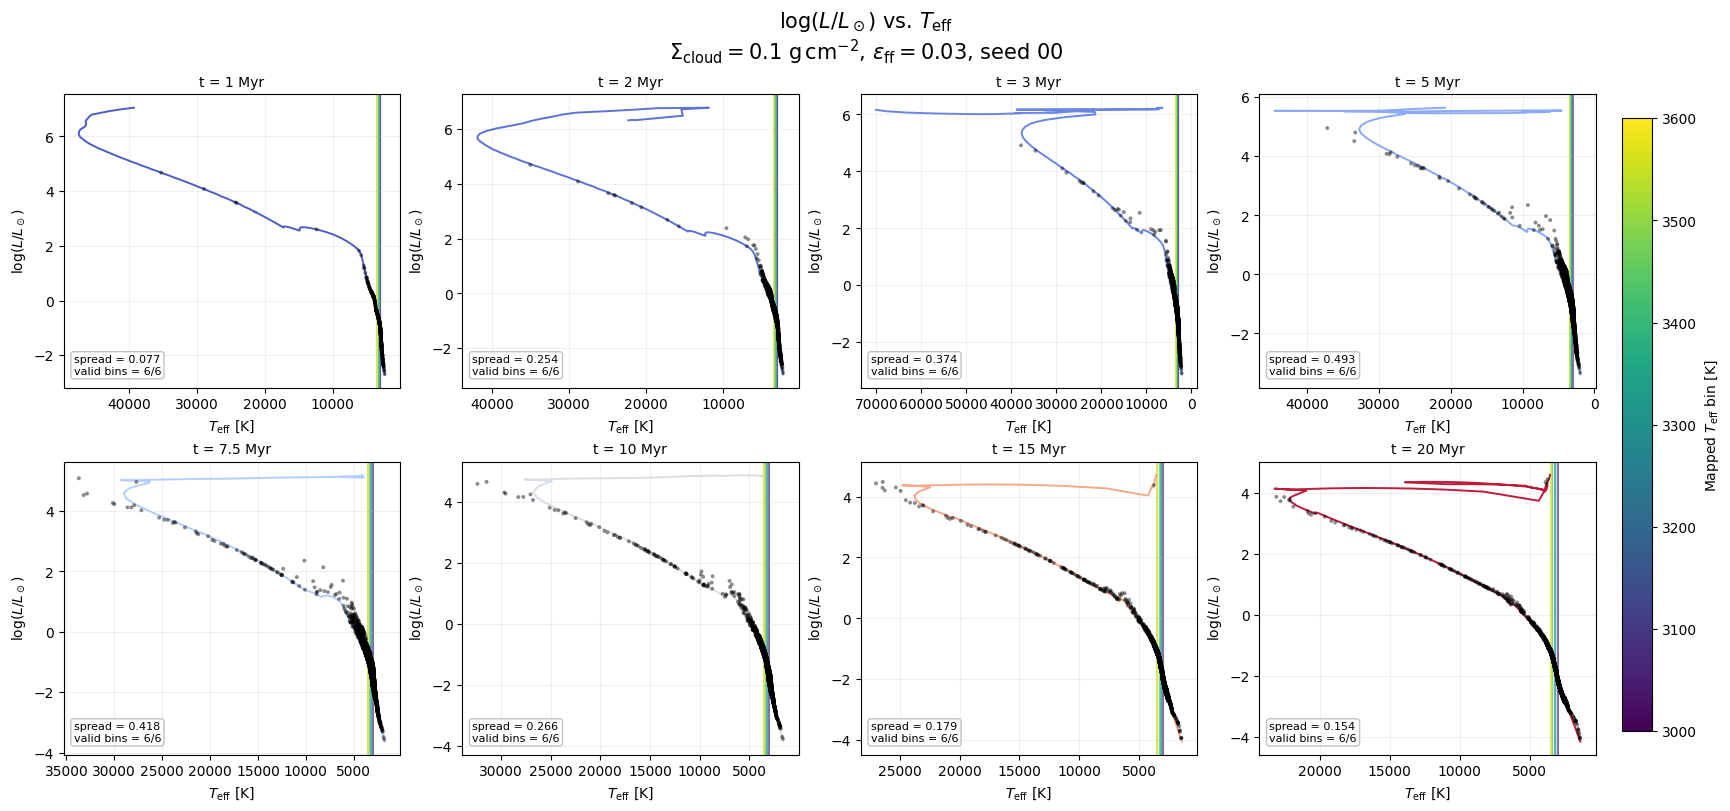

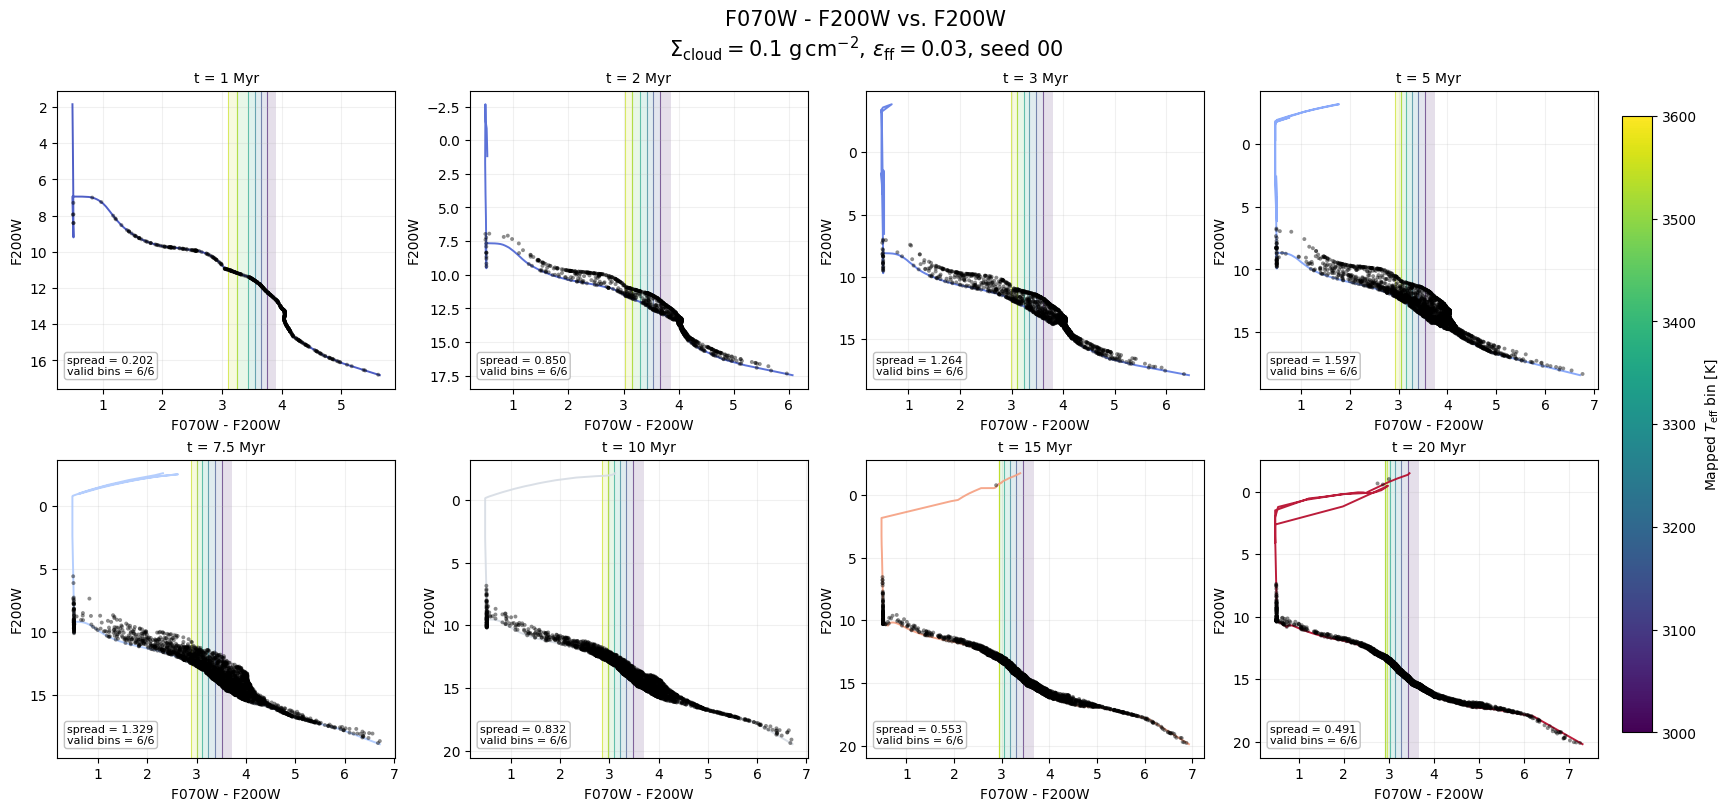

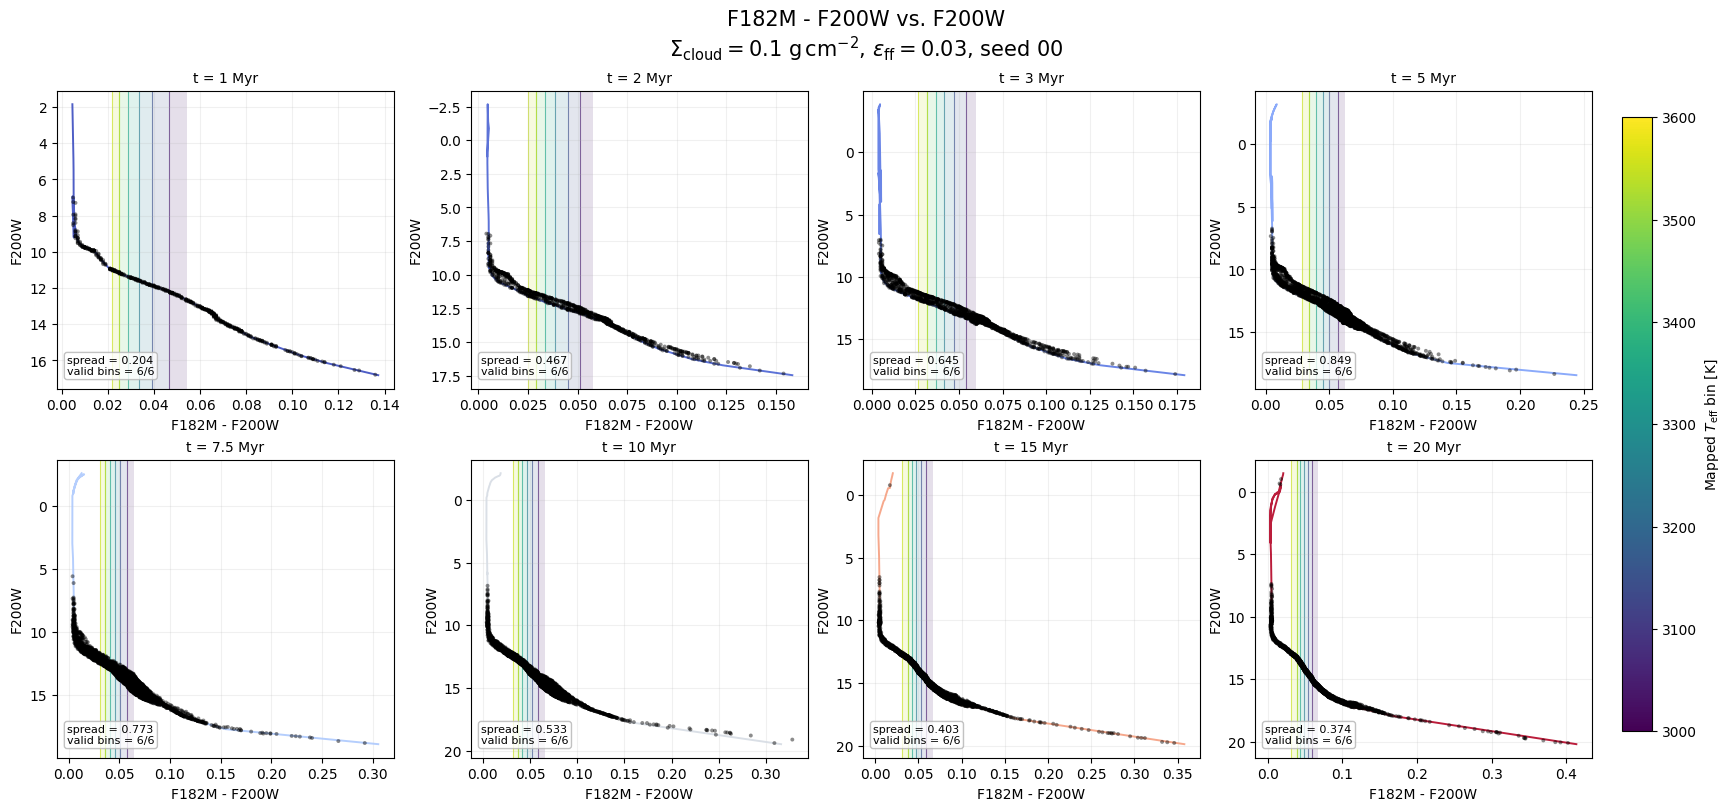

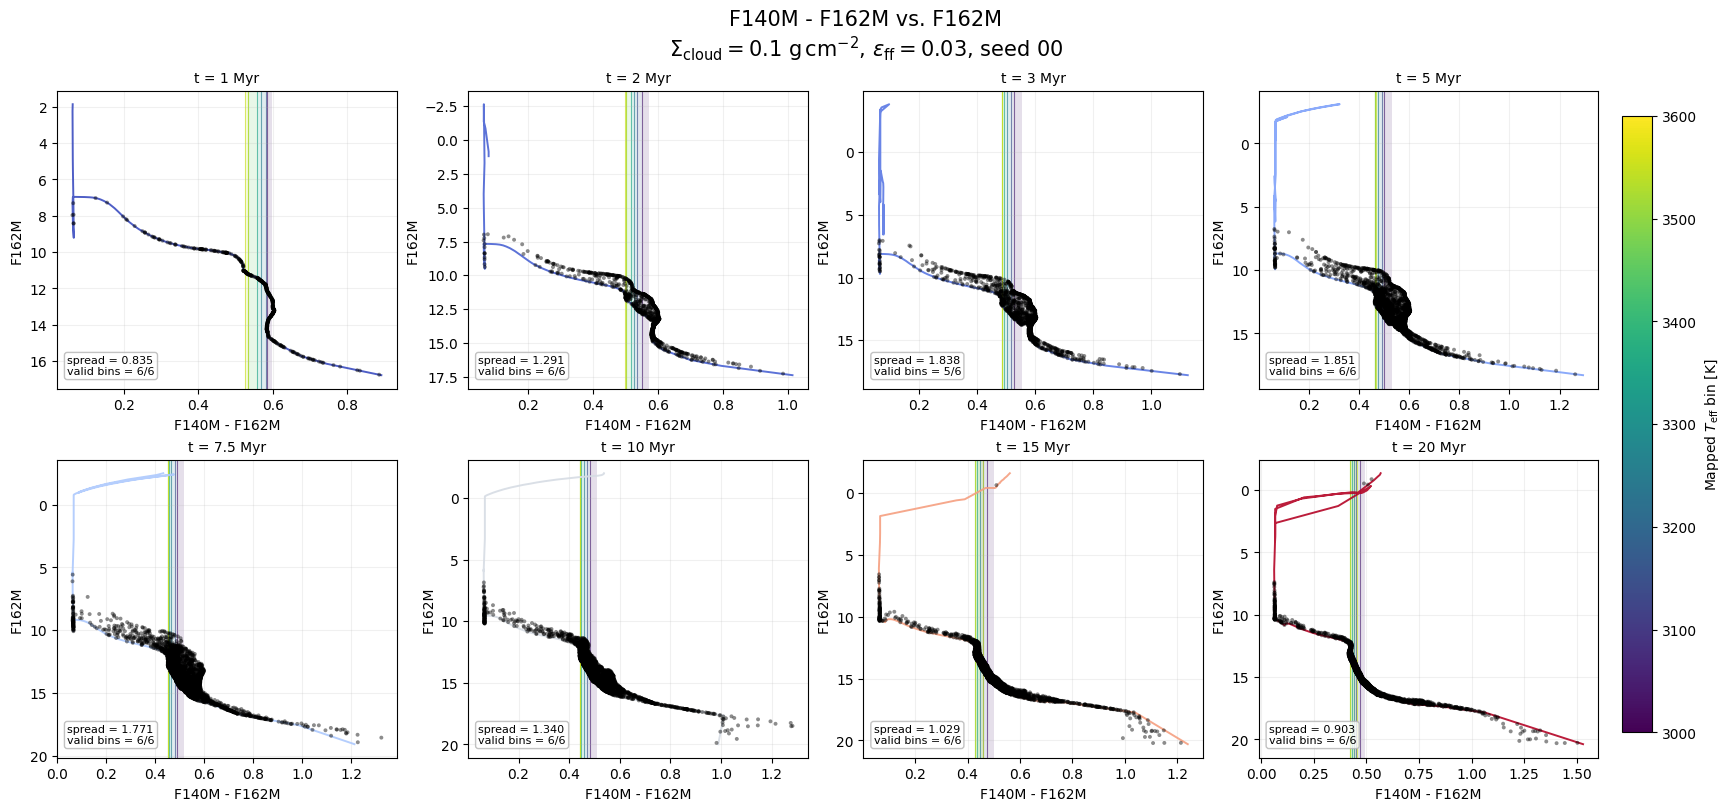

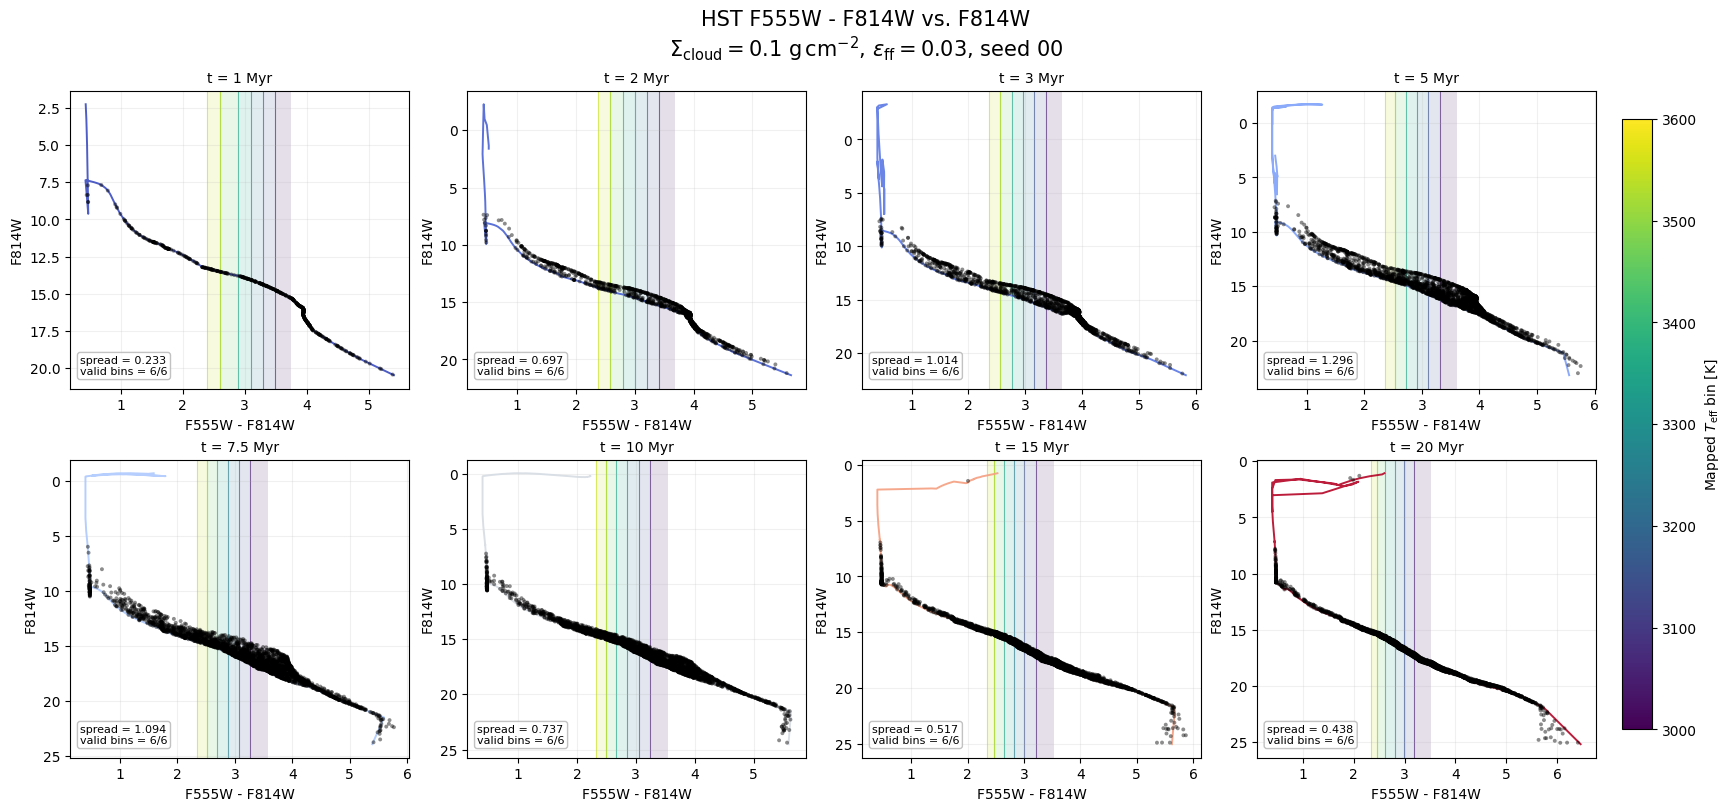

In [11]:
for diagram in DIAGRAMS:
    plot_time_evolution(diagram)

## Ensemble spread-metric evolution

The requested raw ensemble figure places all five tracks on one axis.
The H-R metric is in dex; the CMD metrics are in magnitudes. A second,
normalized figure is also saved for comparing only evolution shape.

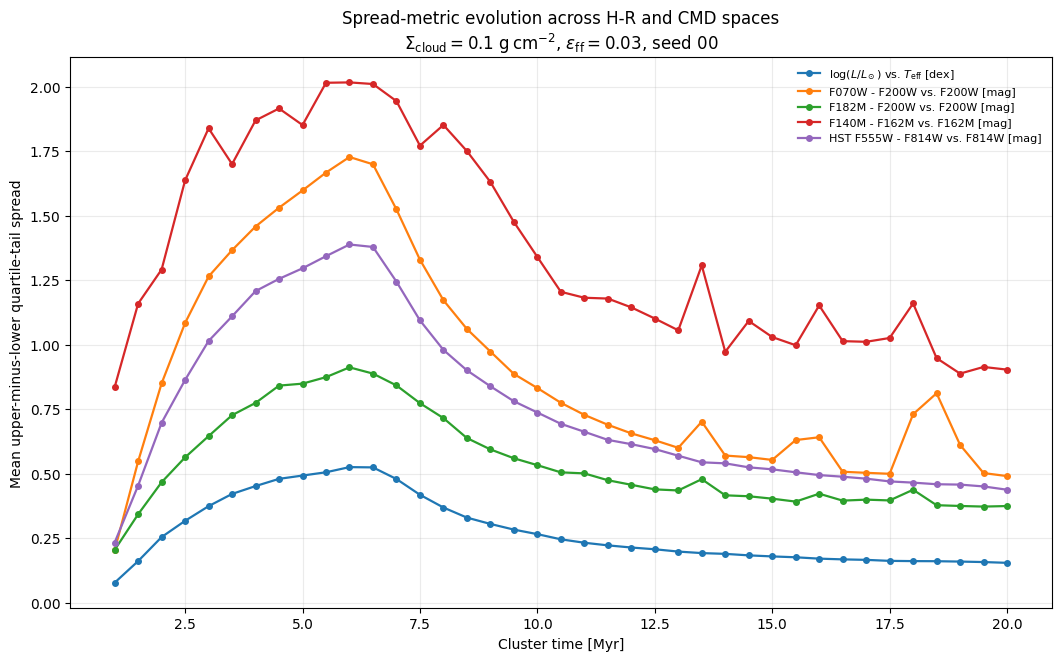

In [12]:
fig, ax = plt.subplots(figsize=(10.5, 6.5), constrained_layout=True)
for diagram in DIAGRAMS:
    subset = df_metrics[df_metrics['diagram'] == diagram.key].sort_values('snapshot_time_myr')
    if subset.empty:
        continue
    unit = 'dex' if diagram.kind == 'hr' else 'mag'
    ax.plot(
        subset['snapshot_time_myr'], subset['spread_metric'],
        marker='o', markersize=4, linewidth=1.6,
        label=f'{diagram.title} [{unit}]',
    )
ax.set_xlabel('Cluster time [Myr]')
ax.set_ylabel('Mean upper-minus-lower quartile-tail spread')
ax.set_title(
    'Spread-metric evolution across H-R and CMD spaces\n'
    + r'$\Sigma_{\rm cloud}=0.1\ {\rm g\,cm^{-2}}$, '
    + r'$\epsilon_{\rm ff}=0.03$, seed 00'
)
ax.grid(alpha=0.25)
ax.legend(fontsize=8, frameon=False)
finish_figure(fig, 'ensemble_spread_metric_evolution.png')

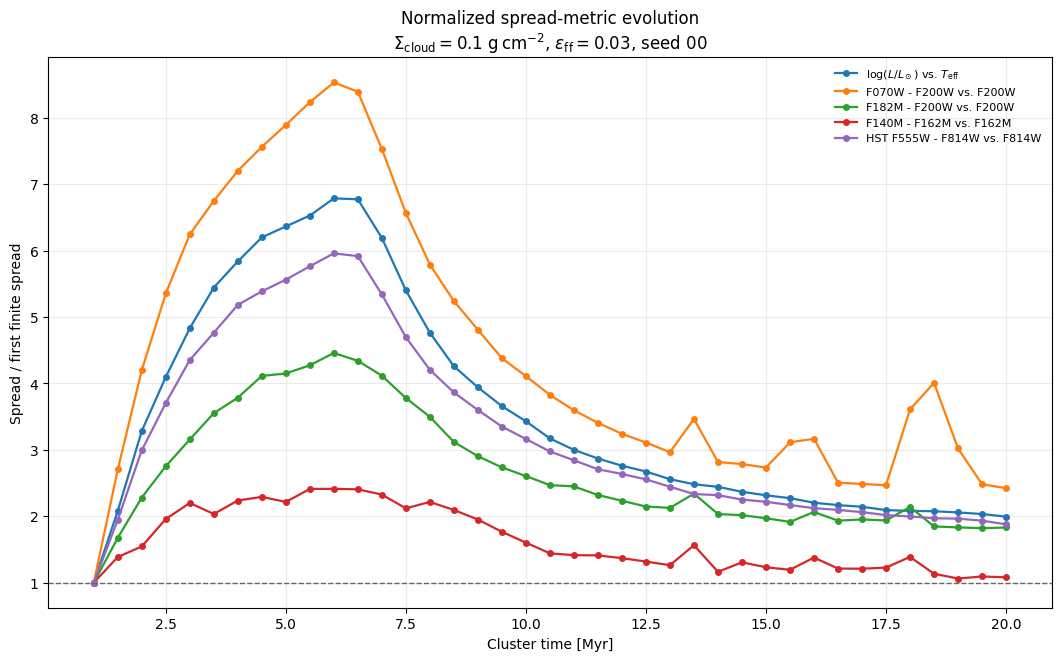

In [13]:
fig, ax = plt.subplots(figsize=(10.5, 6.5), constrained_layout=True)
for diagram in DIAGRAMS:
    subset = df_metrics[df_metrics['diagram'] == diagram.key].sort_values('snapshot_time_myr').copy()
    subset = subset[np.isfinite(subset['spread_metric'])]
    if subset.empty:
        continue
    baseline = float(subset.iloc[0]['spread_metric'])
    if np.isclose(baseline, 0.0):
        continue
    ax.plot(
        subset['snapshot_time_myr'], subset['spread_metric'] / baseline,
        marker='o', markersize=4, linewidth=1.6, label=diagram.title,
    )
ax.axhline(1.0, color='0.4', linestyle='--', linewidth=1.0)
ax.set_xlabel('Cluster time [Myr]')
ax.set_ylabel('Spread / first finite spread')
ax.set_title(
    'Normalized spread-metric evolution\n'
    + r'$\Sigma_{\rm cloud}=0.1\ {\rm g\,cm^{-2}}$, '
    + r'$\epsilon_{\rm ff}=0.03$, seed 00'
)
ax.grid(alpha=0.25)
ax.legend(fontsize=8, frameon=False)
finish_figure(fig, 'ensemble_spread_metric_evolution_normalized.png')

## Output summary

In [14]:
print(f'Outputs saved in: {OUTPUT_DIR.resolve()}')
print('Time-evolution figures:')
for diagram in DIAGRAMS:
    print(f'  time_evolution_{diagram.key}.png')
print('Ensemble figures:')
print('  ensemble_spread_metric_evolution.png')
print('  ensemble_spread_metric_evolution_normalized.png')
print('CSV tables:')
print('  spread_metrics_by_time_and_diagram.csv')
print('  spread_metrics_per_bin.csv')
print('  snapshot_accounting.csv')

Outputs saved in: /sfs/gpfs/tardis/home/wyz5rge/synthetic-cmd-dev/notebooks/2026/07-30_cmd-suite-test/single_sim_multi_diagram_spread_outputs
Time-evolution figures:
  time_evolution_hr.png
  time_evolution_f070w_f200w.png
  time_evolution_f182m_f200w.png
  time_evolution_f140m_f162m.png
  time_evolution_hst_f555w_f814w.png
Ensemble figures:
  ensemble_spread_metric_evolution.png
  ensemble_spread_metric_evolution_normalized.png
CSV tables:
  spread_metrics_by_time_and_diagram.csv
  spread_metrics_per_bin.csv
  snapshot_accounting.csv
